In [1]:
import os
import sys

# Absolute path to the project root
PROJECT_ROOT = os.path.abspath("..")

# Add it to Python's import path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)
print(sys.path[:3])

c:\Users\user\Documents\GitHub\portfolio-optimization
['c:\\Users\\user\\Documents\\GitHub\\portfolio-optimization', 'C:\\Users\\user\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip', 'C:\\Users\\user\\AppData\\Local\\Programs\\Python\\Python310\\DLLs']


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_all_assets
from src.preprocessing import (
    clean_data,
    calculate_daily_returns,
    rolling_statistics
)

In [3]:
datasets = load_all_assets()

Saved TSLA -> data/processed\TSLA.csv
Saved BND -> data/processed\BND.csv
Saved SPY -> data/processed\SPY.csv


In [4]:
tsla = rolling_statistics(
            calculate_daily_returns(
                clean_data(datasets["TSLA"])
            )
)

spy = rolling_statistics(
            calculate_daily_returns(
                clean_data(datasets["SPY"])
            )
)

bnd = rolling_statistics(
            calculate_daily_returns(
                clean_data(datasets["BND"])
            )
)

In [5]:
tsla.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Daily Return,Rolling Mean,Rolling Std
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,,,
0,2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,NaN,NaN,NaN
1,2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,-0.042041,NaN,NaN
2,2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,0.005664,NaN,NaN
3,2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,-0.001562,NaN,NaN
4,2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,-0.001564,NaN,NaN


In [6]:
from src.eda import (
    plot_closing_prices,
    plot_daily_returns,
    plot_rolling_statistics,
    detect_outliers
)

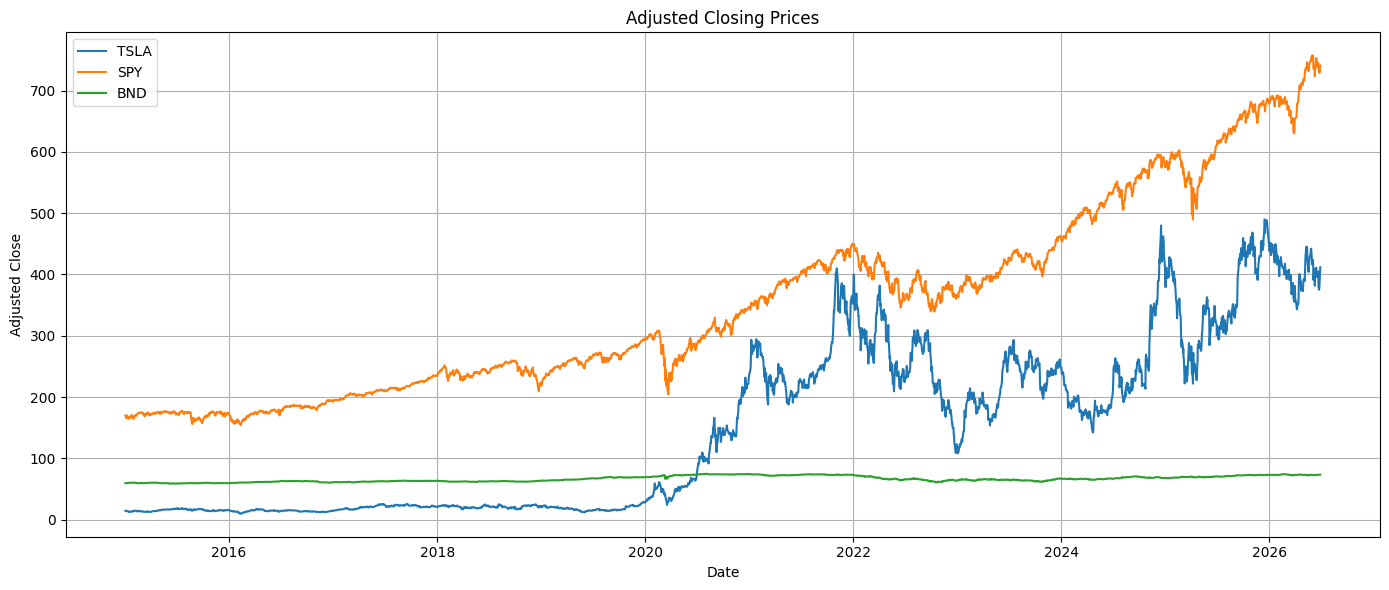

In [7]:
plot_closing_prices({
    "TSLA": tsla,
    "SPY": spy,
    "BND": bnd
})

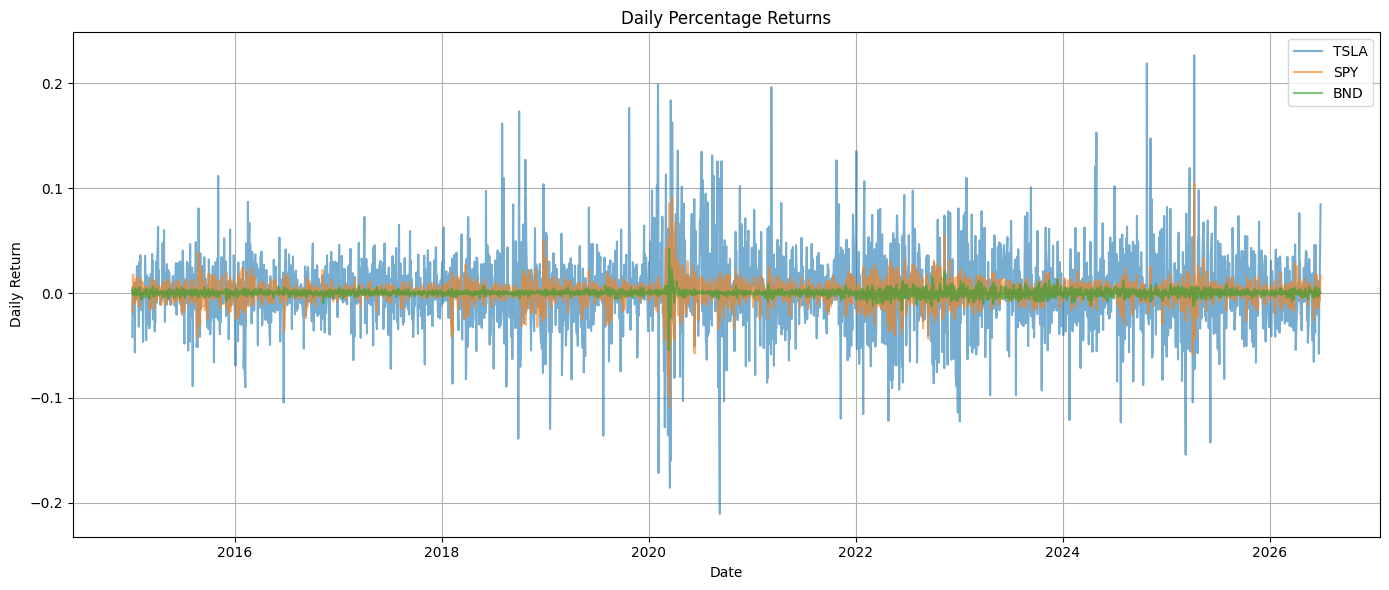

In [8]:
plot_daily_returns({
    "TSLA": tsla,
    "SPY": spy,
    "BND": bnd
})

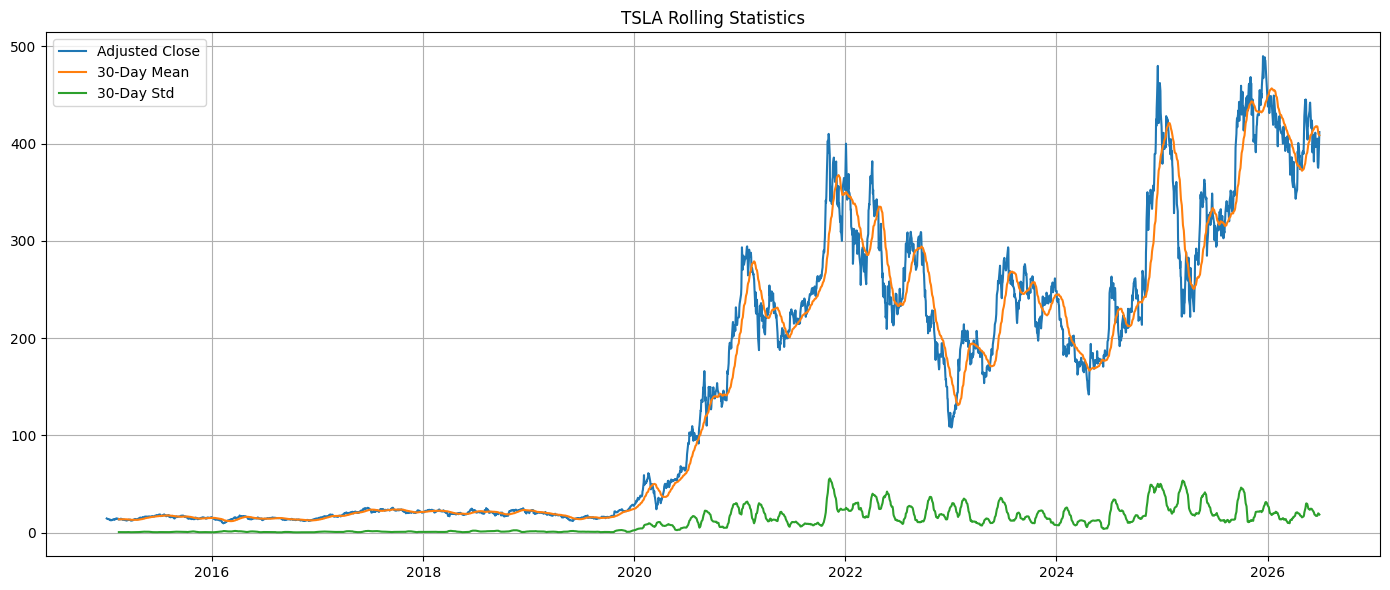

In [9]:
plot_rolling_statistics(tsla, "TSLA")

In [10]:
outliers = detect_outliers(tsla)

outliers[["Date","Daily Return"]]

Price,Date,Daily Return
Ticker,,
212,2015-11-04,0.111735
902,2018-08-02,0.161880
905,2018-08-07,0.109886
942,2018-09-28,-0.139015
943,2018-10-01,0.173471
959,2018-10-23,0.127189
1018,2019-01-18,-0.129711
1147,2019-07-25,-0.136137
1211,2019-10-24,0.176692


In [11]:
print(f"Number of outlier days: {len(outliers)}")

Number of outlier days: 46


In [12]:
for name, df in {
    "TSLA": tsla,
    "SPY": spy,
    "BND": bnd
}.items():
    print("="*50)
    print(name)
    print(df.describe())

TSLA
Price                            Date    Adj Close        Close         High  \
Ticker                                        TSLA         TSLA         TSLA   
count                            2888  2888.000000  2888.000000  2888.000000   
mean    2020-09-27 06:13:27.756232704   148.773923   148.773923   151.990563   
min               2015-01-02 00:00:00     9.578000     9.578000    10.331333   
25%               2017-11-12 06:00:00    18.393499    18.393499    18.665168   
50%               2020-09-26 12:00:00   133.437668   133.437668   136.053329   
75%               2023-08-10 06:00:00   251.925831   251.925831   257.485008   
max               2026-06-29 00:00:00   489.880005   489.880005   498.829987   
std                               NaN   138.895957   138.895957   141.852818   

Price           Low         Open        Volume Daily Return Rolling Mean  \
Ticker         TSLA         TSLA          TSLA                             
count   2888.000000  2888.000000  2.888000

In [13]:
for name, df in {
    "TSLA": tsla,
    "SPY": spy,
    "BND": bnd
}.items():
    print(name)
    print(df.isnull().sum())
    print()

TSLA
Price         Ticker
Date                     0
Adj Close     TSLA       0
Close         TSLA       0
High          TSLA       0
Low           TSLA       0
Open          TSLA       0
Volume        TSLA       0
Daily Return             1
Rolling Mean            29
Rolling Std             29
dtype: int64

SPY
Price         Ticker
Date                     0
Adj Close     SPY        0
Close         SPY        0
High          SPY        0
Low           SPY        0
Open          SPY        0
Volume        SPY        0
Daily Return             1
Rolling Mean            29
Rolling Std             29
dtype: int64

BND
Price         Ticker
Date                     0
Adj Close     BND        0
Close         BND        0
High          BND        0
Low           BND        0
Open          BND        0
Volume        BND        0
Daily Return             1
Rolling Mean            29
Rolling Std             29
dtype: int64



In [14]:
from src.stationarity import adf_test

In [15]:
print("TSLA Closing Price")
print(adf_test(tsla["Adj Close"]))

TSLA Closing Price
{'ADF Statistic': np.float64(-1.069599139417746), 'p-value': np.float64(0.7270419411549222), 'Lags Used': 27, 'Observations': 2860}


In [16]:
print("TSLA Daily Returns")
print(adf_test(tsla["Daily Return"]))

TSLA Daily Returns
{'ADF Statistic': np.float64(-53.971892804251446), 'p-value': 0.0, 'Lags Used': 0, 'Observations': 2886}


The ADF test on adjusted closing prices produced a high p-value, indicating the series is non-stationary. After transforming the data into daily returns, the p-value dropped below 0.05, suggesting the return series is stationary. This supports using differencing for ARIMA modeling, since ARIMA assumes stationarity.

In [17]:
from src.risk_metrics import (
    value_at_risk,
    sharpe_ratio
)

In [18]:
for name, df in {
    "TSLA": tsla,
    "SPY": spy,
    "BND": bnd
}.items():

    print(name)
    print("VaR:", value_at_risk(df["Daily Return"]))
    print("Sharpe:", sharpe_ratio(df["Daily Return"]))
    print()

TSLA
VaR: -0.051663755152845575
Sharpe: 0.7594581853138577

SPY
VaR: -0.01665010773605832
Sharpe: 0.7041778875674112

BND
VaR: -0.004756017869603411
Sharpe: -0.0008098251054697185



Summary of Findings

TSLA exhibited the highest volatility and strongest long-term growth among the three assets.
SPY showed steady growth with moderate volatility, reflecting diversified market performance.
BND remained comparatively stable with smaller price fluctuations, making it suitable as a low-risk asset.
Outlier analysis identified several days with unusually large returns, particularly for TSLA.
The ADF test indicated that closing prices were generally non-stationary, while daily returns were stationary, supporting the use of differencing in ARIMA models.
Historical Value at Risk (VaR) and Sharpe Ratio demonstrated that TSLA offered higher potential returns but also greater risk, whereas BND provided more stable risk-adjusted performance.

In [19]:
from src.models import (
    train_test_split_time_series,
    fit_arima,
    forecast,
    evaluate
)

In [20]:
train, test = train_test_split_time_series(tsla)

print(train.shape)
print(test.shape)

train.tail()

(2516, 10)
(372, 10)


Price,Date,Adj Close,Close,High,Low,Open,Volume,Daily Return,Rolling Mean,Rolling Std
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,,,
2511,2024-12-24,462.279999,462.279999,462.779999,435.140015,435.899994,59551800,0.073572,379.754000,49.404128
2512,2024-12-26,454.130005,454.130005,465.329987,451.019989,465.160004,76366400,-0.017630,383.942000,50.227029
2513,2024-12-27,431.660004,431.660004,450.000000,426.500000,449.519989,82666800,-0.049479,387.322667,49.899939
2514,2024-12-30,417.410004,417.410004,427.000000,415.750000,419.399994,64941000,-0.033012,390.863668,48.045056
2515,2024-12-31,403.839996,403.839996,427.929993,402.540009,423.790009,76825100,-0.032510,393.634334,46.222642


In [21]:
print(train["Date"].max())
print(test["Date"].min())

2024-12-31 00:00:00
2025-01-02 00:00:00


In [22]:
model = fit_arima(
    train["Adj Close"],
    order=(5,1,0)
)

In [23]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2516
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -8180.940
Date:                Sun, 05 Jul 2026   AIC                          16373.881
Time:                        21:46:49   BIC                          16408.861
Sample:                             0   HQIC                         16386.576
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0050      0.012     -0.410      0.682      -0.029       0.019
ar.L2          0.0100      0.011      0.947      0.344      -0.011       0.031
ar.L3         -0.0092      0.013     -0.728      0.4

In [24]:
predictions = forecast(
    model,
    len(test)
)

In [25]:
metrics = evaluate(
    test["Adj Close"],
    predictions
)

metrics

{'MAE': 54.144857271186545,
 'RMSE': np.float64(69.90139832395208),
 'MAPE': 0.17104549222415405}

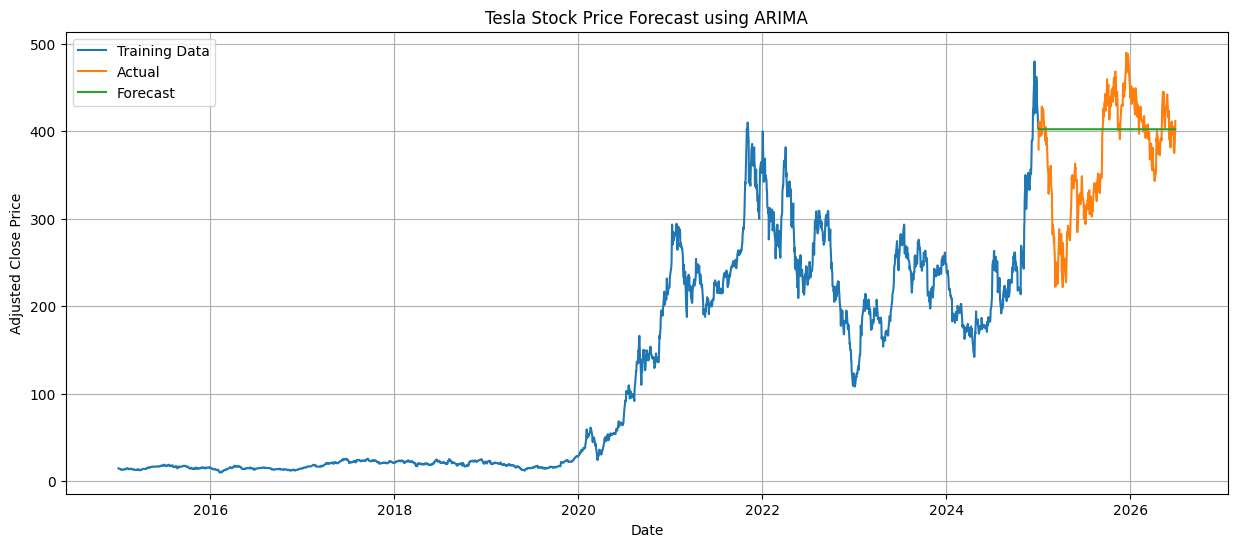

In [26]:
plt.figure(figsize=(15,6))

plt.plot(
    train["Date"],
    train["Adj Close"],
    label="Training Data"
)

plt.plot(
    test["Date"],
    test["Adj Close"],
    label="Actual"
)

plt.plot(
    test["Date"],
    predictions,
    label="Forecast"
)

plt.title("Tesla Stock Price Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
import importlib
import src.models

importlib.reload(src.models)

from src.models import auto_fit_arima

In [30]:
from src.models import auto_fit_arima

auto_model = auto_fit_arima(
    train["Adj Close"]
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=1.69 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.32 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.621 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        21:50:03   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
    

auto_arima selected ARIMA(0,1,0), indicating that no autoregressive (AR) or moving average (MA) terms improved the model. This suggests that Tesla's adjusted closing prices behave similarly to a random walk after first-order differencing.

ARIMA Model Discussion

The dataset was split chronologically into a training set (2015–2024) and a testing set (2025–2026) to preserve the temporal structure of the data and prevent data leakage.

The auto_arima procedure selected ARIMA(0,1,0) as the optimal model based on the lowest Akaike Information Criterion (AIC = 16368.11). This model represents a random walk, meaning that the best prediction for the next day's stock price is largely based on the current price rather than more complex autoregressive or moving average components.

This result aligns with the Efficient Market Hypothesis (EMH), which states that historical price information alone contains limited predictive power because available information is quickly incorporated into market prices. Consequently, simple random-walk models often perform as well as more complex ARIMA models for stock price forecasting.

The model's forecasting performance was evaluated using MAE, RMSE, and MAPE on the testing dataset. These metrics provide a quantitative assessment of prediction accuracy and will be compared with the LSTM model in the final project to determine which approach offers better forecasting performance.